# Chapter 1: When a Score Becomes a Skill

A controller receives a new model version and its benchmark suddenly turns green. That visual change can feel like the arrival of a new skill. Yet the evaluator might be doing something much simpler: turning a gradual score increase into a pass flag at a fixed cutoff. The same outputs can support a smooth curve and a sudden-looking staircase.

This notebook holds the supplied continuous scores fixed while changing the threshold. The experiment gives measurement its own place in the system boundary. Model change, measurement change, and environment change are different hypotheses, and a green cell cannot distinguish them. Begin by drawing the raw scores before looking at the binary result. Ask which evidence would remain if the cutoff moved.

**Outcome:** Compare continuous evidence and thresholded scores without attributing a mechanism.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

Let s(x) be a supplied continuous score at scale x. The thresholded score is B_tau(x)=1{s(x)>=tau}. A discontinuity in B_tau can occur whenever s crosses tau, even if s itself has no sharp change. This construction is a property of the measurement rule. It does not require a discontinuity inside the model.

Adjacent raw-score slopes are [s(x_i)-s(x_(i-1))]/[x_i-x_(i-1)]. They have score-per-scale units, so the scale definition matters. Replacing model size with its logarithm would change their numerical meaning. The implementation requires strictly increasing scales to keep these slopes defined and aligned.

Crossing count measures adjacent changes in the binary score, including downward crossings. It is not a statistical test for emergence. With only a handful of supplied points, many different underlying functions could interpolate the observations. A useful evaluation contract therefore declares the task, scoring rule, scale variable, environment, and uncertainty before attaching a mechanism label.

## A calculation you can run

Provide aligned lists of increasing scales and scores between zero and one. Set the threshold separately. Validation rejects a repeated scale, mismatched vector lengths, nonfinite values, and a cutoff outside the score domain. The function calculates the pass flags, adjacent raw slopes, and number of binary crossings.

The two figures share scale on the horizontal axis. The continuous chart shows score movement; the binary chart shows the measurement transformation. Compare their shapes before making any claim about new ability. In the changed case only the threshold moves from 0.5 to 0.55. The scores and scale values remain fixed. That choice isolates a measurement intervention from a model intervention. The returned interpretation keeps this distinction explicit.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 1
inputs = {'scales': [1, 2, 3, 4, 5], 'scores': [0.42, 0.46, 0.49, 0.52, 0.56], 'threshold': 0.5}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 1: score-threshold
Did capability jump, or did the scoring rule create a cliff?
Evidence: constructed teaching example

Calculated quantities:
{
  "thresholded_scores": [
    0,
    0,
    0,
    1,
    1
  ],
  "crossing_count": 1,
  "max_raw_slope": 0.04
}

Interpretation:
A jump in the thresholded curve may come from the scoring rule even when the supplied continuous scores change gradually.

Assumptions:
- The same task, output boundary, and environment apply across scales.

Limitations:
- This diagnostic neither identifies a neural mechanism nor proves a phase transition.

Execution: completed locally; constructed inputs are not deployment measurements.


At threshold 0.5, the default flags are 0,0,0,1,1. There is one crossing between scales 3 and 4. The raw scores rise by only a few hundredths at each interval, and the largest adjacent slope is 0.04 score units per scale unit.

At threshold 0.55, the flags become 0,0,0,0,1. The location of the apparent skill arrival moves to the last observation without changing a single score. The binary jump is real as a reported measurement. The unsupported inference would be that it identifies a sudden internal mechanism or a universal capability boundary.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


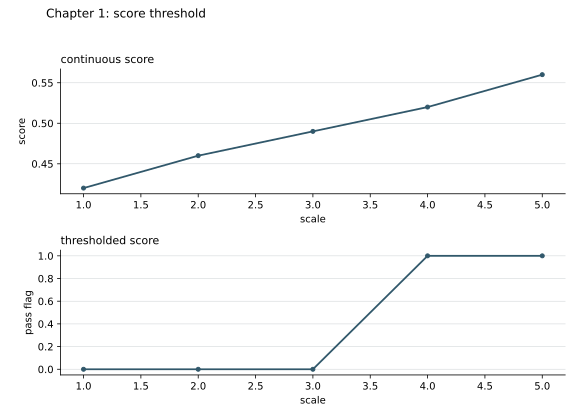

In [3]:
display(SVG(figure_svg(report)))

**Figure 1.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

A threshold diagnostic can fail through overinterpretation even when its arithmetic is correct. The raw curve might conceal a genuinely sharp change between sampled scales, or the score might be a noisy estimate with a broad uncertainty interval. This notebook does not settle either possibility because it receives no replicate measurements and fits no mechanism model.

A second failure comes from comparing scores produced under different tasks or environments. A larger score can result from an easier prompt, a changed tool interface, or a more forgiving evaluator. Those changes need separate records. The computation validates numeric alignment, but it cannot verify that the rows share a scientific contract. Keep the source of every score beside the figure and use a matched experiment to isolate the part of the assembled system being changed.

Chapter 1: score-threshold
Did capability jump, or did the scoring rule create a cliff?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "thresholded_scores": [
    0,
    0,
    0,
    0,
    1
  ],
  "crossing_count": 1,
  "max_raw_slope": 0.04
}

Interpretation:
A jump in the thresholded curve may come from the scoring rule even when the supplied continuous scores change gradually.

Assumptions:
- The same task, output boundary, and environment apply across scales.

Limitations:
- This diagnostic neither identifies a neural mechanism nor proves a phase transition.

Execution: completed locally; constructed inputs are not deployment measurements.


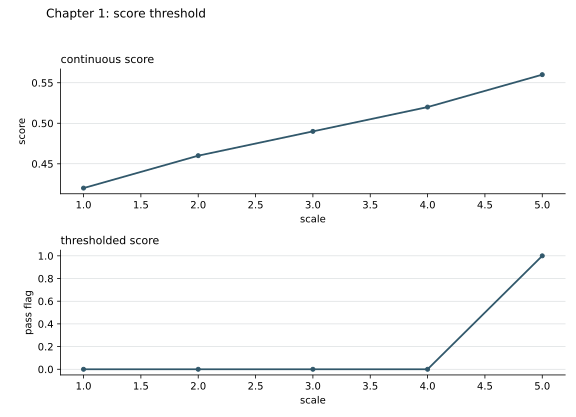

In [4]:
changed_inputs = {'scales': [1, 2, 3, 4, 5], 'scores': [0.42, 0.46, 0.49, 0.52, 0.56], 'threshold': 0.55}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 1.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer data uses a wider scale range and stronger raw-score movement. Its cutoff of 0.7 produces a pass only at the final point. Calculate the adjacent slopes with their unequal scale intervals before describing the curve. A score increase of 0.3 over 20 scale units is not the same local rate as an increase of 0.2 over 40 units.

For local data, retain the original continuous outcome wherever possible. If only pass/fail results were saved, record that loss of information rather than reconstructing an invented smooth curve. The next useful measurement is the pre-threshold score or a set of outcomes under several declared cutoffs.

In [5]:
transfer_inputs = {'scales': [10, 20, 40, 80], 'scores': [0.1, 0.3, 0.6, 0.8], 'threshold': 0.7}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 1: score-threshold
Did capability jump, or did the scoring rule create a cliff?
Evidence: constructed transfer example

Calculated quantities:
{
  "thresholded_scores": [
    0,
    0,
    0,
    1
  ],
  "crossing_count": 1,
  "max_raw_slope": 0.02
}

Interpretation:
A jump in the thresholded curve may come from the scoring rule even when the supplied continuous scores change gradually.

Assumptions:
- The same task, output boundary, and environment apply across scales.

Limitations:
- This diagnostic neither identifies a neural mechanism nor proves a phase transition.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **scales:** Finite strictly increasing numeric scale values.
- **scores:** Aligned continuous task scores in [0,1].
- **threshold:** Pass cutoff in [0,1].

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch01.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 1: score-threshold
Did capability jump, or did the scoring rule create a cliff?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "thresholded_scores": [
    0,
    0,
    0,
    1
  ],
  "crossing_count": 1,
  "max_raw_slope": 0.02
}

Interpretation:
A jump in the thresholded curve may come from the scoring rule even when the supplied continuous scores change gradually.

Assumptions:
- The same task, output boundary, and environment apply across scales.

Limitations:
- This diagnostic neither identifies a neural mechanism nor proves a phase transition.

Execution: completed locally; constructed inputs are not deployment measurements.


## Questions

1. List default pass flags.

2. Does changing only the cutoff prove model change?

3. What is the first transfer slope?

Answers: [separate solutions](../solutions/ch01.md). Try the calculation before opening them.

## Summary

Thresholding can turn gradual score movement into an abrupt reported jump. Compare raw and transformed scores under a fixed evaluation contract, then test whether the conclusion survives a cutoff change. The figures describe supplied observations, not an internal mechanism. Preserve scale units, task definitions, and measurement provenance. A pass flag is an outcome of the scoring rule; calling it a skill requires a separate operational definition and evidence that the declared ability transfers to the tasks that matter.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-01-score-threshold`](../skills/maa-01-score-threshold/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 1.1

![Equation 1.1](../assets/math/2f04db7ed24c43b56a6e.svg)

Equation (1.1) draws the book's first system boundary by naming the model as a probability law over outputs given context, and nothing more.

Given a context $c$, this returns the model's whole distribution over possible next tokens $z$, one number for every token, rather than a single answer.

LaTeX source, preserved for inspection:

```latex
K_\theta(z\mid c)=\Pr_\theta(Z=z\mid C=c).
\tag{1.1}
```

### Equation 1.2

![Equation 1.2](../assets/math/7024d1950a99dfdb39d6.svg)

Equation (1.2) compresses everything a model did on a test set into one number: the fraction of prompts a fixed rule was willing to call a success.

For each prompt, generate an output, run the declared evaluator, and score one or zero; the reported number is the average of those verdicts.

LaTeX source, preserved for inspection:

```latex
\widehat U_{\mathcal V}(\{\theta\})=\frac{1}{n}\sum_{i=1}^{n}
\mathbf{1}\{\operatorname{eval}_\tau(\hat z_i)=1\}.
\tag{1.2}
```

### Equation 1.3

![Equation 1.3](../assets/math/358feec511b08285a077.svg)

Equation (1.3) separates the three places a task result can move: the model's distribution, the rule that picks one output, and the rule that judges it.

Start at the left with the model's law, apply the decoding rule to get one output, then apply the evaluator to get the judged result; each arrow is a place a change can enter.

LaTeX source, preserved for inspection:

```latex
K_\theta(z\mid c)
\longrightarrow
\hat z=\operatorname{dec}\bigl(K_\theta(\cdot\mid c)\bigr)
\longrightarrow
y=\operatorname{eval}_\tau(\hat z,c).
\tag{1.3}
```

### Equation 1.4

![Equation 1.4](../assets/math/92f634db554ae0d71c49.svg)

Equation (1.4) converts a smooth per-token improvement into a task score that moves at a completely different rate, using nothing but multiplication.

Raise the per-token success probability to the power of the target length; in logarithms the same statement says the target length multiplies whatever the model gained per token.

LaTeX source, preserved for inspection:

```latex
U=q^{n},
\qquad\text{so}\qquad
\log U = n\log q.
\tag{1.4}
```